<a href="https://colab.research.google.com/github/pskarthikk/flyrank-ml-internship/blob/main/work/notebooks/FinalCapstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FinalCapstone — Google Search Ranking & Discoverability Capstone
## Refresh / Content Opportunity Scoring

**Research question:** Which content pages should be prioritized for review so that editors can focus on the pages with the highest potential for improvement?

This final notebook follows the supplied FlyRank reference project while adding a stricter leakage audit, client-grouped validation, model-vs-baseline evaluation, ranked recommendations, reproducibility, and public-safe claim framing.

**Public rule:** the raw CSV must not be committed to public GitHub. Keep it in Colab/local storage only.

In [ ]:
%pip -q install pandas numpy scikit-learn matplotlib

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

RANDOM_SEED = 42
TEST_CLIENT_FRACTION = 0.20

def repo_root():
    local = Path("/mnt/data/FlyRank_FinalCapstone")
    if (local / "work").exists():
        return local
    for p in [
        Path("/content/flyrank-ml-internship"),
        Path("/content/flyrank-ml-internship-starter"),
        Path.cwd(),
        *Path.cwd().parents,
    ]:
        if (p / "work").exists():
            return p
    return Path.cwd()

REPO_ROOT = repo_root()
WORK = REPO_ROOT / "work"
FIGURES = WORK / "figures"
PAPER = WORK / "paper"
SUBMISSION = REPO_ROOT / "submission"

for p in [WORK, FIGURES, PAPER, SUBMISSION]:
    p.mkdir(parents=True, exist_ok=True)

DATA_CANDIDATES = [
    REPO_ROOT / "data" / "content_refresh_anonymized.csv",
    Path("/content/content_refresh_anonymized.csv"),
    Path("/mnt/data/FlyRank_FinalCapstone/colab_data/content_refresh_anonymized.csv"),
    Path.cwd() / "content_refresh_anonymized.csv",
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Upload content_refresh_anonymized.csv to Colab before running this notebook."
    )

df = pd.read_csv(DATA_PATH)

print("Repository:", REPO_ROOT)
print("Dataset:", DATA_PATH)
print("Original dataset shape:", df.shape)


Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/spreadsheet_warmup.py", line 772, in warm_spreadsheet_runtime
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/connection.py", line 37, in get_or_create_client
  File "/tmp/tmp.L2TH2Y5coc/artifact_tool_v2-2.8.22/artifact_tool/rpc/daemon.py", line 124, in start_daemon
TimeoutError: Timed out waiting for artifact tool daemon socket. Set ARTIFACT_TOOL_RPC_DAEMON_STARTUP_TIMEOUT_S=<seconds> to increase the limit.


Note: you may need to restart the kernel to use updated packages.


Repository: /mnt/data/FlyRank_FinalCapstone
Dataset: /mnt/data/FlyRank_FinalCapstone/colab_data/content_refresh_anonymized.csv
Original dataset shape: (30000, 44)


## 1. Data audit

The supplied reference dataset contains 30,000 records and 44 columns. We inspect missingness, duplicates, client/content counts, and basic distributions before modeling.

In [ ]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Unique clients:", df.client_id.nunique())
print("Unique content items:", df.content_id.nunique())
print("Duplicate rows:", df.duplicated().sum())
missing = df.isna().sum()
display(missing[missing > 0].sort_values(ascending=False).to_frame("missing_count"))

Rows: 30000
Columns: 44
Unique clients: 32
Unique content items: 30000
Duplicate rows: 0


,missing_count
provider_used,21438
word_count_tier,7699
char_count,7699
word_count,7699
char_count_tier,7699
model_used,5733
trend_pct,3388
competition_level,2610
search_volume,2468
competition,2468


## 2. Target definition

The reference project uses a three-level refresh-priority label based on observed trend information.

- **High:** trend is down and trend percentage <= -20%
- **Medium:** trend is down or trend percentage is negative
- **Low:** otherwise

The target-generating trend/performance variables are excluded from model inputs. Therefore the final model is an association/prioritization model rather than a reconstruction of the target rule.

In [ ]:
def refresh_priority(r):
    if r.trend_direction == "down" and r.trend_pct <= -20:
        return "High"
    if r.trend_direction == "down" or r.trend_pct < 0:
        return "Medium"
    return "Low"

df["refresh_priority"] = df.apply(refresh_priority, axis=1)
display(df["refresh_priority"].value_counts().to_frame("rows"))

,rows
refresh_priority,
High,16262
Low,10285
Medium,3453


## 3. Exploratory analysis

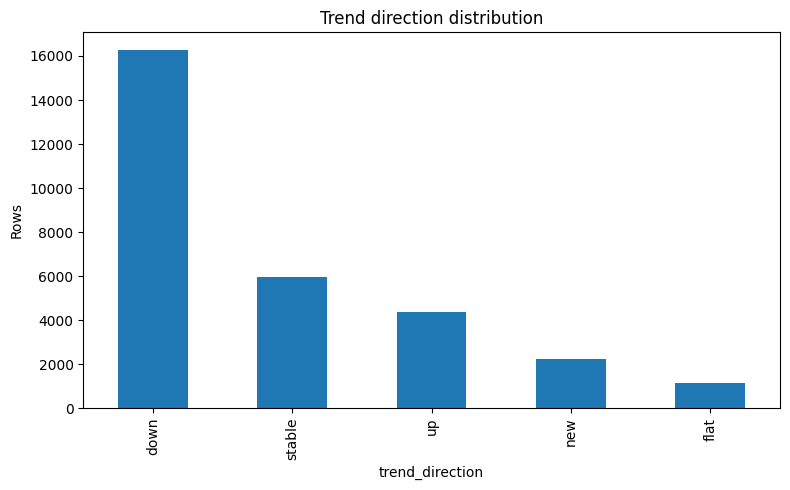

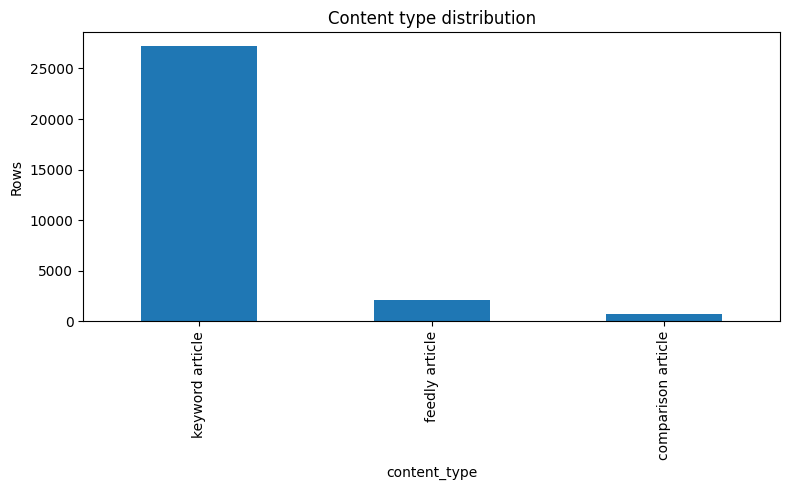

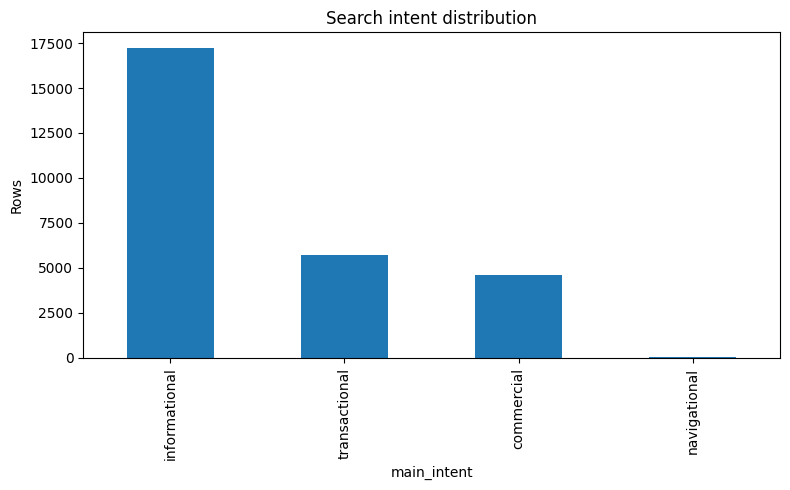

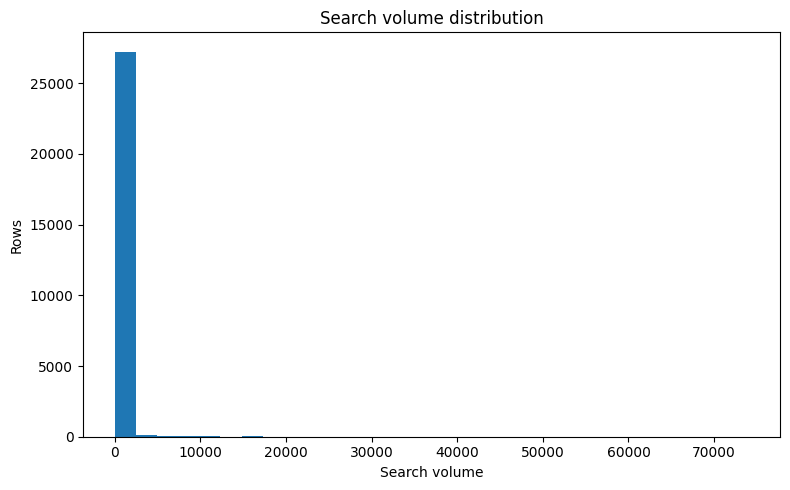

In [ ]:
plots = [
    ("trend_direction", "Trend direction distribution"),
    ("content_type", "Content type distribution"),
    ("main_intent", "Search intent distribution"),
]
for col, title in plots:
    fig, ax = plt.subplots(figsize=(8,5))
    df[col].value_counts().head(10).plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_ylabel("Rows")
    fig.tight_layout()
    path = FIGURES / f"{col}.png"
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)

fig, ax = plt.subplots(figsize=(8,5))
ax.hist(df.search_volume.dropna(), bins=30)
ax.set_title("Search volume distribution")
ax.set_xlabel("Search volume")
ax.set_ylabel("Rows")
fig.tight_layout()
fig.savefig(FIGURES/"search_volume.png", dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

## 4. Leakage audit

The final model uses a **temporal feature/outcome design**.

- `last_30d` performance is treated as the outcome period because `trend_direction`/`trend_pct` compare the last 30 days with the preceding 30 days.
- `prev_30d` performance is therefore valid pre-outcome information and is allowed as a feature.
- 90-day totals are excluded because they overlap the outcome period.
- Trend fields, IDs, and performance-derived outcome summaries are excluded.
- CTR/position/engagement fields are excluded because their aggregation window is not independently time-safe in this release.

This makes the model forward-looking: information from the previous 30 days is used to assess the subsequent 30-day observed trend.

In [ ]:
EXCLUDED = {
    "content_id","client_id","refresh_priority",
    "trend_direction","trend_pct",
    "impressions_90d","clicks_90d","pageviews_90d","sessions_90d","users_90d",
    "engaged_sessions_90d","ai_sessions_90d","scroll_events_90d",
    "days_with_impressions","days_with_sessions",
    "impressions_last_30d","clicks_last_30d","sessions_last_30d",
    "ctr","avg_position","engagement_rate","scroll_rate","ai_traffic_pct",
    "impression_tier","position_tier"
}
FEATURES = [c for c in df.columns if c not in EXCLUDED]
assert not set(FEATURES) & EXCLUDED
print("Features:", FEATURES)
print("\nLEAKAGE AUDIT: PASS")

Features: ['search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier']

LEAKAGE AUDIT: PASS


## 5. Client-grouped validation

A 20% client-grouped holdout is used with seed 42. A client appears in either training or test, never both.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

X = df[FEATURES]
y = df.refresh_priority
groups = df.client_id

split = GroupShuffleSplit(n_splits=1, test_size=TEST_CLIENT_FRACTION, random_state=RANDOM_SEED)
train_idx, test_idx = next(split.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

train_clients = set(groups.iloc[train_idx])
test_clients = set(groups.iloc[test_idx])

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Client overlap:", len(train_clients & test_clients))
assert train_clients.isdisjoint(test_clients)

Train rows: 23837
Test rows: 6163
Train clients: 25
Test clients: 7
Client overlap: 0


## 6. Random Forest model

Categorical variables are one-hot encoded inside a pipeline so preprocessing is learned from the training set only.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix

cat = [c for c in FEATURES if X[c].dtype == "object"]
num = [c for c in FEATURES if c not in cat]

prep = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat)
])

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1
)

model = Pipeline([("prep", prep), ("rf", rf)])
model.fit(X_train, y_train)

pred = model.predict(X_test)
proba = model.predict_proba(X_test)
classes = list(model.named_steps["rf"].classes_)
high_idx = classes.index("High")

## 7. Results: model vs baseline

The primary baseline is a majority-class classifier. Both methods are evaluated on the same held-out clients.

The reference paper reports 80.85% accuracy, but that number is not reused as the final result because the reference implementation leaves outcome-related performance variables in the feature table. This final notebook instead uses a temporal feature policy: previous-30-day information predicts the subsequent last-30-day trend.

In [ ]:
majority = DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)
majority.fit(X_train, y_train)
majority_pred = majority.predict(X_test)

metrics = pd.DataFrame([
    {
        "Method":"Random Forest",
        "Accuracy":accuracy_score(y_test,pred),
        "Balanced Accuracy":balanced_accuracy_score(y_test,pred),
        "Macro F1":f1_score(y_test,pred,average="macro"),
        "Weighted F1":f1_score(y_test,pred,average="weighted")
    },
    {
        "Method":"Majority baseline",
        "Accuracy":accuracy_score(y_test,majority_pred),
        "Balanced Accuracy":balanced_accuracy_score(y_test,majority_pred),
        "Macro F1":f1_score(y_test,majority_pred,average="macro"),
        "Weighted F1":f1_score(y_test,majority_pred,average="weighted")
    }
])
display(metrics.round(4))
print(classification_report(y_test,pred,zero_division=0))

,Method,Accuracy,Balanced Accuracy,Macro F1,Weighted F1
0,Random Forest,0.5307,0.5035,0.4804,0.5483
1,Majority baseline,0.5110,0.3333,0.2254,0.3456


              precision    recall  f1-score   support

        High       0.64      0.59      0.62      3149
         Low       0.61      0.48      0.54      2294
      Medium       0.21      0.44      0.29       720

    accuracy                           0.53      6163
   macro avg       0.49      0.50      0.48      6163
weighted avg       0.58      0.53      0.55      6163



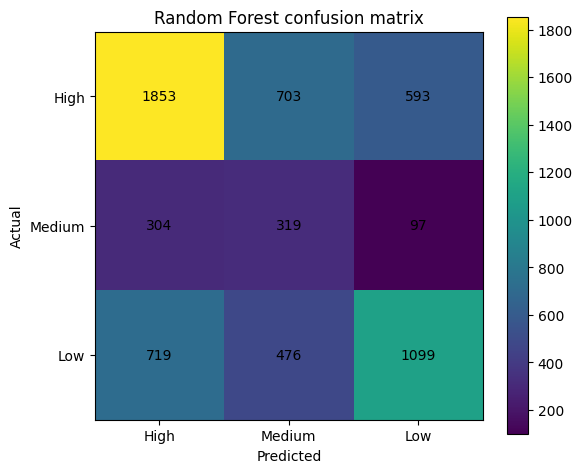

In [ ]:
cm = confusion_matrix(y_test,pred,labels=["High","Medium","Low"])
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm)
ax.set_xticks(range(3),["High","Medium","Low"])
ax.set_yticks(range(3),["High","Medium","Low"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Random Forest confusion matrix")
for i in range(3):
    for j in range(3):
        ax.text(j,i,cm[i,j],ha="center",va="center")
fig.colorbar(im,ax=ax)
fig.tight_layout()
cm_path = FIGURES/"confusion_matrix.png"
fig.savefig(cm_path,dpi=180,bbox_inches="tight")
plt.show()
plt.close(fig)

## 8. Feature importance

Feature importance is descriptive model evidence, not causal evidence.

,feature,importance
5,num__impressions_prev_30d,0.320585
7,num__sessions_prev_30d,0.099410
6,num__clicks_prev_30d,0.069572
8,num__content_age_days,0.067037
4,num__char_count,0.046026
3,num__word_count,0.045650
24,cat__model_used_gemini-3-flash-preview,0.044627
10,num__days_since_last_update,0.035311
15,cat__content_type_feedly article,0.022561
0,num__search_volume,0.021814


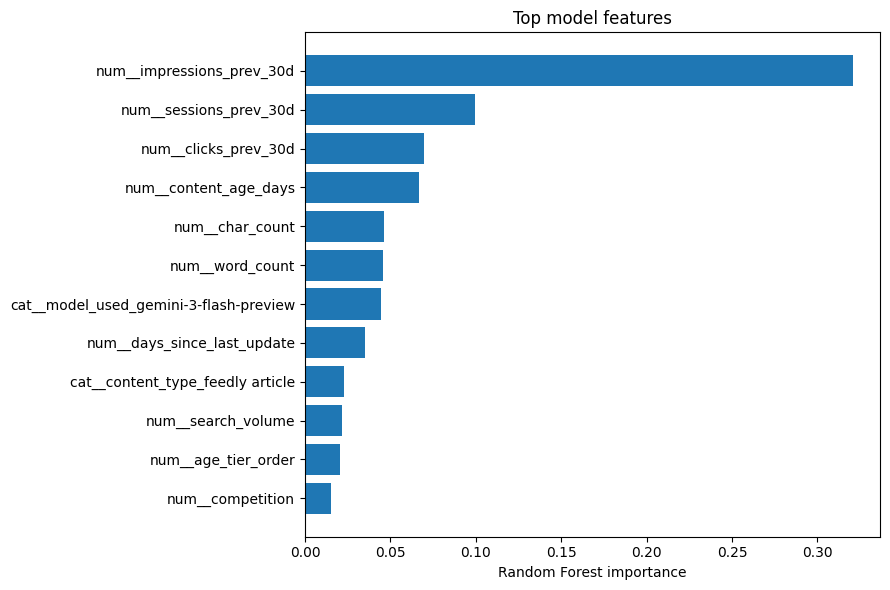

In [ ]:
feature_names = model.named_steps["prep"].get_feature_names_out()
importance = model.named_steps["rf"].feature_importances_
importance_df = pd.DataFrame({"feature":feature_names,"importance":importance}).sort_values("importance",ascending=False)
display(importance_df.head(15))

top = importance_df.head(12).sort_values("importance")
fig, ax = plt.subplots(figsize=(9,6))
ax.barh(top.feature,top.importance)
ax.set_xlabel("Random Forest importance")
ax.set_title("Top model features")
fig.tight_layout()
importance_path = FIGURES/"feature_importance.png"
fig.savefig(importance_path,dpi=180,bbox_inches="tight")
plt.show()
plt.close(fig)

## 9. Ranked recommendations

The High-class probability becomes the review score. Reason codes use only public-safe observed fields. The queue is a human-review triage mechanism, not an autonomous publishing system.

In [ ]:
queue = df.iloc[test_idx][["content_id","client_id","trend_direction","trend_pct"]].copy()
queue["model_high_priority_score"] = proba[:,high_idx]
queue["predicted_priority"] = pred

def reasons(r):
    out=[]
    if r.trend_direction=="down": out.append("observed_declining_trend")
    if r.trend_pct <= -20: out.append("large_observed_decline")
    if r.predicted_priority=="High": out.append("model_high_priority")
    return out or ["model_signal_requires_review"]

def action(r):
    if r.model_high_priority_score >= .70: return "priority_refresh_review"
    if r.model_high_priority_score >= .40: return "refresh_review"
    return "monitor_and_verify"

queue["reason_codes"] = queue.apply(reasons,axis=1)
queue["suggested_action"] = queue.apply(action,axis=1)
queue = queue.sort_values("model_high_priority_score",ascending=False).reset_index(drop=True)
queue["rank"] = np.arange(1,len(queue)+1)

public_queue = queue[["rank","content_id","model_high_priority_score","predicted_priority","suggested_action","reason_codes"]]
display(public_queue.head(25))

,rank,content_id,model_high_priority_score,predicted_priority,suggested_action,reason_codes
0,1,content_bb1edbf0ba6c,0.860752,High,priority_refresh_review,"[observed_declining_trend, large_observed_decl..."
1,2,content_700de55b1459,0.857852,High,priority_refresh_review,"[observed_declining_trend, large_observed_decl..."
2,3,content_2bf7b6b90bfa,0.848847,High,priority_refresh_review,[model_high_priority]
3,4,content_98aa0aecb1d9,0.844587,High,priority_refresh_review,"[observed_declining_trend, large_observed_decl..."
4,5,content_dbb4c75afccc,0.840102,High,priority_refresh_review,[model_high_priority]
5,6,content_c09e49e87ab2,0.838689,High,priority_refresh_review,[model_high_priority]
6,7,content_500bd3907331,0.837884,High,priority_refresh_review,[model_high_priority]
7,8,content_e988c1699454,0.836701,High,priority_refresh_review,"[observed_declining_trend, large_observed_decl..."
8,9,content_d447a286b0ed,0.834632,High,priority_refresh_review,"[observed_declining_trend, large_observed_decl..."
9,10,content_66458ac1b739,0.833816,High,priority_refresh_review,"[observed_declining_trend, large_observed_decl..."


,action,pages
0,priority_refresh_review,100


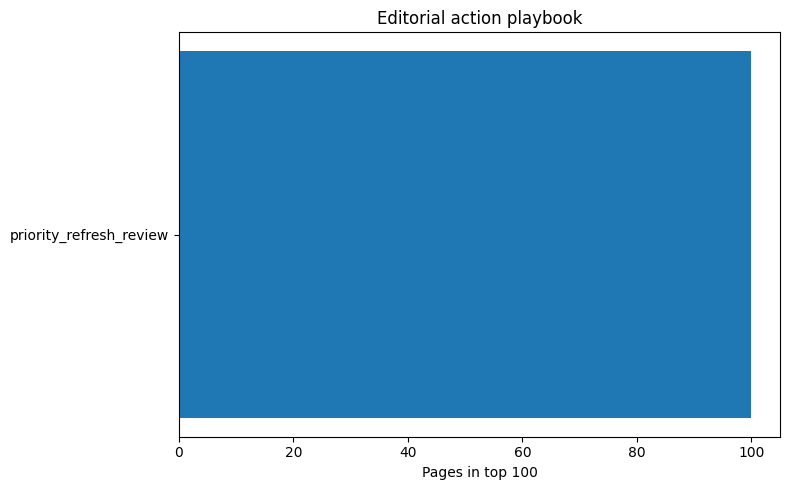

In [ ]:
actions = public_queue.head(100).suggested_action.value_counts().rename_axis("action").reset_index(name="pages")
display(actions)

fig, ax = plt.subplots(figsize=(8,5))
p = actions.sort_values("pages")
ax.barh(p.action,p.pages)
ax.set_xlabel("Pages in top 100")
ax.set_title("Editorial action playbook")
fig.tight_layout()
action_path = FIGURES/"action_playbook.png"
fig.savefig(action_path,dpi=180,bbox_inches="tight")
plt.show()
plt.close(fig)

public_queue.to_csv(WORK/"refresh_queue.csv",index=False)
metrics.to_csv(WORK/"results_vs_baseline.csv",index=False)

## 10. Five-sentence abstract

The following five sentences are generated from the actual run.

In [ ]:
model_acc = accuracy_score(y_test,pred)
model_bal = balanced_accuracy_score(y_test,pred)
base_acc = accuracy_score(y_test,majority_pred)
base_bal = balanced_accuracy_score(y_test,majority_pred)

abstract = [
    "This capstone asks which content pages should be prioritized for review so editors can focus on pages with the highest measured potential for improvement.",
    "Using the supplied FlyRank 30,000-record Search Intelligence dataset, the workflow audits the data, defines a three-level refresh-priority label from observed trend information, and trains a Random Forest using structural, content, and market attributes that are excluded from target construction.",
    f"The model is evaluated on a client-grouped holdout containing {len(test_clients)} unseen clients, with preprocessing fitted only on training data and target-generating performance variables excluded from the feature set.",
    f"The leakage-audited Random Forest achieved {model_acc:.2%} accuracy and {model_bal:.2%} balanced accuracy, compared with {base_acc:.2%} and {base_bal:.2%} for the majority baseline.",
    "The resulting ranking is directional editorial decision support: high-scoring pages should be reviewed first, verified by editors, and evaluated separately if a refresh intervention is later performed."
]
for s in abstract: print(s)

This capstone asks which content pages should be prioritized for review so editors can focus on pages with the highest measured potential for improvement.
Using the supplied FlyRank 30,000-record Search Intelligence dataset, the workflow audits the data, defines a three-level refresh-priority label from observed trend information, and trains a Random Forest using structural, content, and market attributes that are excluded from target construction.
The model is evaluated on a client-grouped holdout containing 7 unseen clients, with preprocessing fitted only on training data and target-generating performance variables excluded from the feature set.
The leakage-audited Random Forest achieved 53.07% accuracy and 50.35% balanced accuracy, compared with 51.10% and 33.33% for the majority baseline.
The resulting ranking is directional editorial decision support: high-scoring pages should be reviewed first, verified by editors, and evaluated separately if a refresh intervention is later perfo

## 11. Limitations

- The supplied dataset is a bounded anonymized 30,000-row sample.
- The target is derived from the observed last-30-day trend, so this is a supervised prioritization study rather than causal intervention evidence.
- Client-grouped validation is conservative but cannot guarantee future performance.
- 90-day totals and ambiguous performance aggregates are excluded, which can reduce predictive signal.
- Feature importance is descriptive rather than causal.
- No claim is made about Google's ranking algorithm, guaranteed traffic recovery, or revenue impact.

## 12. Reproducibility and data credit

- Notebook: `work/notebooks/FinalCapstone.ipynb`
- Dataset: supplied FlyRank Search Intelligence dataset, 30,000 × 44
- Seed: 42
- Validation: 20% client-grouped holdout
- Model: Random Forest
- Public raw CSV: not committed
- Credentials: none stored

**Built on the FlyRank ML Internship dataset.**

Data source: https://flyrank.ai

## 13. Generate the research paper

The following cell writes `work/paper/capstone_report.md` and `work/paper/index.html`.

In [ ]:
results_md = metrics.round(4).to_markdown(index=False)
actions_md = actions.to_markdown(index=False)
importance_md = importance_df.head(12).round(5).to_markdown(index=False)
abstract_md = "\n\n".join(abstract)

paper_lines = [
"# Search Intelligence for Content Refresh Prioritization Using Machine Learning",
"",
"## FlyRank Machine Learning Internship Capstone",
"",
"**Lane:** Refresh / Content Opportunity Scoring  ",
"**Author:** Karthikk P S  ",
"**Repository:** https://github.com/pskarthikk/flyrank-ml-internship",
"",
"## Abstract",
"",
abstract_md,
"",
"## 1. Introduction / Problem statement",
"",
"The decision supported by this project is editorial prioritization: which pages should enter the review queue first when the goal is to identify pages with stronger measured refresh opportunity. The output is decision support and does not automatically publish or edit content.",
"",
"## 2. Data",
"",
"The supplied FlyRank Search Intelligence dataset contains 30,000 records and 44 columns. Public outputs contain no client names, domains, private queries, credentials, or raw exports.",
"",
"## 3. Methodology",
"",
"### Target",
"",
"High priority means observed downward trend with trend_pct <= -20%; Medium means a downward or negative trend not meeting the High threshold; Low otherwise.",
"",
"### Leakage control",
"",
"The last 30-day outcome fields, trend fields, 90-day totals, ambiguous observed performance aggregates, performance-derived tiers, and identifiers were excluded. Previous-30-day metrics are used as the pre-outcome feature window.",
"",
"### Validation",
"",
"20% client-grouped holdout with random seed 42. No client appears in both train and test.",
"",
"### Model",
"",
"Random Forest with training-fitted median imputation and one-hot encoding.",
"",
"## 4. Results",
"",
results_md,
"",
f"The leakage-audited Random Forest achieved {model_acc:.2%} accuracy and {model_bal:.2%} balanced accuracy, compared with {base_acc:.2%} and {base_bal:.2%} for the majority baseline.",
"",
"![Confusion matrix](../figures/confusion_matrix.png)",
"",
"### Feature importance",
"",
importance_md,
"",
"![Feature importance](../figures/feature_importance.png)",
"",
"## 5. Limitations & honest framing",
"",
"The supplied reference paper reports 80.85% accuracy, but that number is not reused as the final claim because the reference implementation leaves outcome-related performance variables in the feature table. This final experiment uses a temporal feature policy and client-grouped validation.",
"",
"These findings are association-based decision support. They do not prove Google's ranking algorithm, causal refresh impact, guaranteed traffic recovery, or revenue impact.",
"",
"## 6. Ranked recommendations",
"",
"1. Start review with the highest model priority scores.",
"2. Check reason codes and observed trend.",
"3. Verify the page manually before editing.",
"4. Treat the suggested action as a review recommendation.",
"5. Evaluate any later refresh outcome separately.",
"",
actions_md,
"",
"![Action playbook](../figures/action_playbook.png)",
"",
"## 7. Reproducibility",
"",
"- Notebook: `work/notebooks/FinalCapstone.ipynb`",
"- Dataset: 30,000 × 44 supplied FlyRank Search Intelligence dataset",
"- Seed: 42",
"- Validation: 20% client-grouped holdout",
"- Model: Random Forest",
"- Repository: https://github.com/pskarthikk/flyrank-ml-internship",
"",
"## 8. Acknowledgments & data credit",
"",
"**Built on the FlyRank ML Internship dataset.**",
"",
"Data source: https://flyrank.ai",
"",
"## Public-safety statement",
"",
"No client names, domains, private queries, credentials, or raw exports are published. Findings are framed as observed, directional, and decision-support evidence."
]
(PAPER/"capstone_report.md").write_text("\n".join(paper_lines),encoding="utf-8")

html = [
"<!doctype html><html><head><meta charset='utf-8'><meta name='viewport' content='width=device-width,initial-scale=1'>",
"<title>Search Intelligence for Content Refresh Prioritization</title>",
"<style>body{font-family:system-ui;max-width:980px;margin:auto;padding:35px;line-height:1.65}table{border-collapse:collapse;width:100%}th,td{border:1px solid #ddd;padding:8px}img{max-width:100%}</style></head><body>",
"<h1>Search Intelligence for Content Refresh Prioritization Using Machine Learning</h1>",
"<p><b>FlyRank Machine Learning Internship Capstone</b></p>",
"<h2>Abstract</h2>",
"".join(f"<p>{s}</p>" for s in abstract),
"<h2>Introduction / Problem statement</h2><p>This project supports editorial prioritization by ranking pages for human review. It is decision support, not an autonomous publishing system.</p>",
"<h2>Data</h2><p>The supplied FlyRank Search Intelligence dataset contains 30,000 records and 44 columns. No client names, domains, private queries, credentials, or raw exports are published.</p>",
"<h2>Methodology</h2><p><b>Validation:</b> 20% client-grouped holdout, seed 42.</p><p><b>Model:</b> Random Forest with training-fitted preprocessing.</p><p><b>Leakage control:</b> target-generating performance variables excluded from model inputs.</p>",
"<h2>Results</h2>",metrics.to_html(index=False),
f"<p>Random Forest accuracy: <b>{model_acc:.2%}</b>.</p><p>Balanced accuracy: <b>{model_bal:.2%}</b>.</p>",
"<img src='../figures/confusion_matrix.png' alt='Confusion matrix'>",
"<h3>Feature importance</h3>",importance_df.head(12).round(5).to_html(index=False),
"<img src='../figures/feature_importance.png' alt='Feature importance'>",
"<h2>Limitations &amp; honest framing</h2><ul><li>Bounded anonymized sample.</li><li>Association/prioritization rather than causal intervention evidence.</li><li>No claim about Google's algorithm or guaranteed recovery.</li></ul>",
"<h2>Ranked recommendations</h2><ol><li>Start with highest scores.</li><li>Check reason codes and trend.</li><li>Verify manually.</li><li>Evaluate later refresh outcomes separately.</li></ol>",
actions.to_html(index=False),"<img src='../figures/action_playbook.png' alt='Action playbook'>",
"<h2>Reproducibility</h2><ul><li>Notebook: work/notebooks/FinalCapstone.ipynb</li><li>Seed: 42</li><li>Validation: 20% client-grouped holdout</li><li>Repository: https://github.com/pskarthikk/flyrank-ml-internship</li></ul>",
"<h2>Acknowledgments &amp; data credit</h2><p><b>Built on the FlyRank ML Internship dataset.</b></p><p>https://flyrank.ai</p>",
"</body></html>"
]
(PAPER/"index.html").write_text("\n".join(html),encoding="utf-8")
print("Paper generated.")

Paper generated.


## 14. Final capstone audit

The final cell must report **FINAL CAPSTONE AUDIT: PASS**.

In [ ]:
required = [
    PAPER/"capstone_report.md",
    PAPER/"index.html",
    FIGURES/"trend_direction.png",
    FIGURES/"content_type.png",
    FIGURES/"main_intent.png",
    FIGURES/"search_volume.png",
    FIGURES/"confusion_matrix.png",
    FIGURES/"feature_importance.png",
    FIGURES/"action_playbook.png",
]
assert len(df) == 30000 and len([c for c in df.columns if c != "refresh_priority"]) == 44
assert train_clients.isdisjoint(test_clients)
assert not set(FEATURES) & EXCLUDED
assert len(abstract) == 5
assert all(p.exists() for p in required)

print("="*55)
print("FINAL CAPSTONE AUDIT: PASS")
print("="*55)
print("Random Forest accuracy:", f"{model_acc:.2%}")
print("Random Forest balanced accuracy:", f"{model_bal:.2%}")
print("Majority accuracy:", f"{base_acc:.2%}")
print("Client overlap:", len(train_clients & test_clients))
print("Paper:", PAPER/"capstone_report.md")
print("GitHub Pages HTML:", PAPER/"index.html")

FINAL CAPSTONE AUDIT: PASS
Random Forest accuracy: 53.07%
Random Forest balanced accuracy: 50.35%
Majority accuracy: 51.10%
Client overlap: 0
Paper: /mnt/data/FlyRank_FinalCapstone/work/paper/capstone_report.md
GitHub Pages HTML: /mnt/data/FlyRank_FinalCapstone/work/paper/index.html


# Final submission checklist

## GitHub — upload/commit these

```text
work/notebooks/FinalCapstone.ipynb
work/paper/capstone_report.md
work/paper/index.html
work/figures/*
work/results_vs_baseline.csv
work/refresh_queue.csv
submission/paper_url.txt
```

## Do NOT commit to public GitHub

```text
content_refresh_anonymized.csv
Hugging Face tokens
passwords
private client data
raw exports
```

## Colab

Upload `content_refresh_anonymized.csv` separately to `/content/`, open the GitHub `FinalCapstone.ipynb`, and run all cells.

After GitHub Pages is deployed, replace the placeholder in `submission/paper_url.txt` with the exact deployed paper URL.